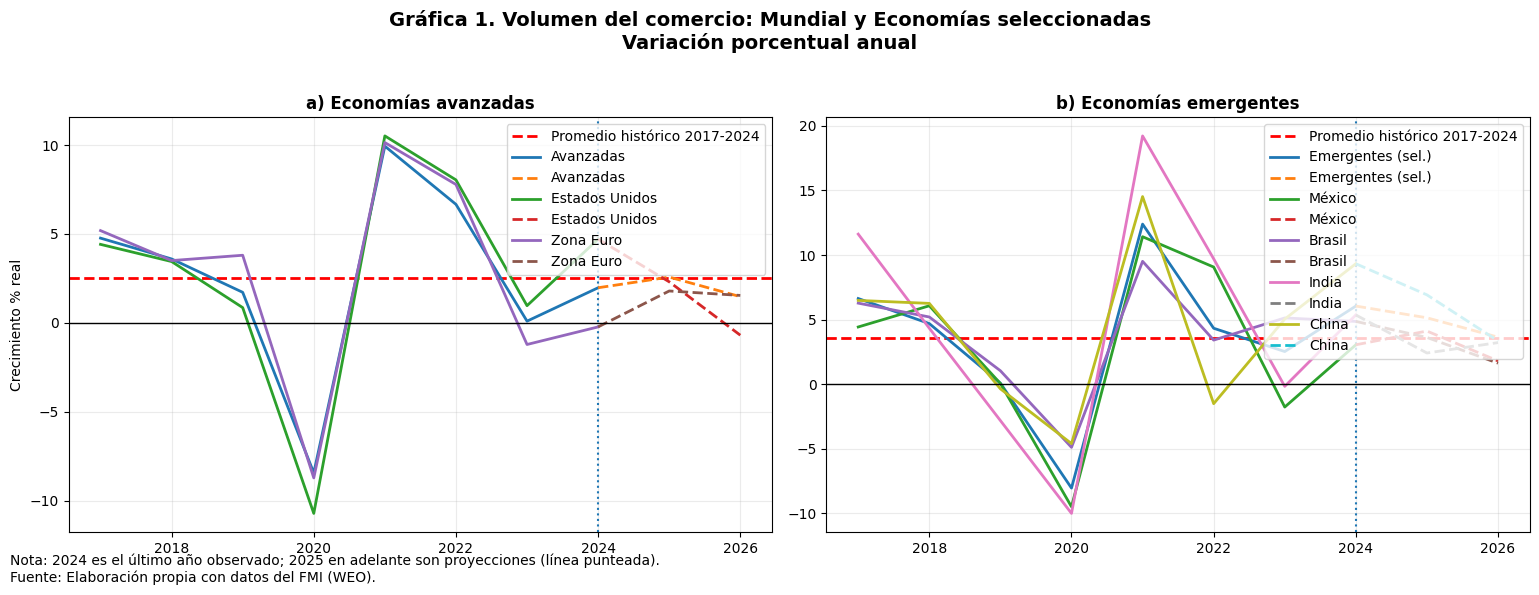

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) Cargar datos
# =========================
# Cambia el path si hace falta
path = "raw/ex_im.csv"
df = pd.read_csv(path)

# Años disponibles (ajusta si tu CSV tiene otros)
years = [c for c in df.columns if c.isdigit()]
years = sorted(years, key=int)
years_int = list(map(int, years))

# =========================
# 2) Helpers
# =========================
def trade_volume_growth(df, country_name, years):
    """
    Calcula crecimiento del 'volumen del comercio' como el promedio
    entre crecimiento real de exportaciones e importaciones (volume).
    Si solo existe una de las dos series, usa esa.
    """
    sub = df[df["COUNTRY"] == country_name].copy()

    # Identificar export/import por el texto del indicador (robusto)
    # (en tu archivo aparecen frases como 'Exports of goods and services, Volume...' y 'Imports...')
    sub["is_export"] = sub["INDICATOR"].str.contains("Exports of goods and services, Volume", case=False, na=False)
    sub["is_import"] = sub["INDICATOR"].str.contains("Imports of goods and services, Volume", case=False, na=False)

    ex = sub[sub["is_export"]]
    im = sub[sub["is_import"]]

    # Convertir a numérico y promediar por si hubiera duplicados
    def mean_series(x):
        if x.empty:
            return None
        return x[years].apply(pd.to_numeric, errors="coerce").mean(axis=0)

    ex_s = mean_series(ex)
    im_s = mean_series(im)

    if ex_s is None and im_s is None:
        raise ValueError(f"No encontré series de export/import volume para: {country_name}")

    if ex_s is None:
        vol = im_s
    elif im_s is None:
        vol = ex_s
    else:
        vol = (ex_s + im_s) / 2.0

    return vol.astype(float)

def plot_solid_then_dashed(ax, x, y, split_year=2024, **kwargs):
    """
    Dibuja línea sólida hasta split_year y punteada después.
    """
    x = np.array(x)
    y = np.array(y, dtype=float)

    mask_solid = x <= split_year
    mask_dashed = x >= split_year  # incluye split_year para que conecte

    # sólida
    ax.plot(x[mask_solid], y[mask_solid], **kwargs)

    # punteada (mismo estilo pero con linestyle='--')
    dashed_kwargs = dict(kwargs)
    dashed_kwargs["linestyle"] = "--"
    ax.plot(x[mask_dashed], y[mask_dashed], **dashed_kwargs)

# =========================
# 3) Series a graficar (subgrupos)
# =========================
# Panel a) Economías avanzadas: grupo + países seleccionados
advanced_series = [
    ("Mundial", "World"),  # si NO existe en tu CSV, bórralo
    ("Avanzadas", "Advanced Economies"),
    ("Estados Unidos", "United States"),
    ("Zona Euro", "Euro Area (EA)"),
]

# Panel b) Economías emergentes: grupo + países seleccionados
emerging_series = [
    ("Emergentes (sel.)", "Emerging Market and Developing Economies"),
    ("México", "Mexico"),
    ("Brasil", "Brazil"),
    ("India", "India"),
    ("China", "China, People's Republic of"),
]

# NOTA: Si tu CSV NO trae "World", comenta esa línea o cámbiala al nombre exacto del país/grupo.

# Parámetros de proyecciones y promedio histórico
last_observed_year = 2024
hist_start, hist_end = 2017, 2024  # cámbialo a 2000-2019 si tienes esos años en el CSV

# =========================
# 4) Construir figura
# =========================
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.5), sharey=False)
fig.suptitle("Gráfica 1. Volumen del comercio: Mundial y Economías seleccionadas\nVariación porcentual anual",
             fontsize=14, fontweight="bold", y=1.02)

# ---------- Panel a ----------
ax = axes[0]
ax.set_title("a) Economías avanzadas", fontsize=12, fontweight="bold")

# Promedio histórico (línea horizontal punteada roja) — usa el grupo "Avanzadas" como referencia
adv_group = trade_volume_growth(df, "Advanced Economies", years)
hist_mask_adv = [(y >= hist_start) and (y <= hist_end) for y in years_int]
hist_avg_adv = float(np.nanmean(adv_group.values[hist_mask_adv]))

ax.axhline(hist_avg_adv, linestyle="--", linewidth=2, color="red", label=f"Promedio histórico {hist_start}-{hist_end}")

# Línea vertical en el último observado
ax.axvline(last_observed_year, linestyle=":", linewidth=1.5)

# Series
for label, country in advanced_series:
    try:
        s = trade_volume_growth(df, country, years)
        plot_solid_then_dashed(ax, years_int, s.values, split_year=last_observed_year, linewidth=2, label=label)
    except ValueError:
        # Si alguna serie no existe, la saltamos sin romper el notebook
        continue

ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("")
ax.set_ylabel("Crecimiento % real")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", frameon=True)

# ---------- Panel b ----------
ax = axes[1]
ax.set_title("b) Economías emergentes", fontsize=12, fontweight="bold")

# Promedio histórico (línea horizontal punteada roja) — usa el grupo "Emergentes"
em_group = trade_volume_growth(df, "Emerging Market and Developing Economies", years)
hist_mask_em = [(y >= hist_start) and (y <= hist_end) for y in years_int]
hist_avg_em = float(np.nanmean(em_group.values[hist_mask_em]))

ax.axhline(hist_avg_em, linestyle="--", linewidth=2, color="red", label=f"Promedio histórico {hist_start}-{hist_end}")

ax.axvline(last_observed_year, linestyle=":", linewidth=1.5)

for label, country in emerging_series:
    try:
        s = trade_volume_growth(df, country, years)
        plot_solid_then_dashed(ax, years_int, s.values, split_year=last_observed_year, linewidth=2, label=label)
    except ValueError:
        continue

ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("")
ax.set_ylabel("")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", frameon=True)

# Nota y fuente
fig.text(0.01, -0.02,
         f"Nota: {last_observed_year} es el último año observado; {last_observed_year+1} en adelante son proyecciones (línea punteada).\n"
         "Fuente: Elaboración propia con datos del FMI (WEO).",
         fontsize=10)

plt.tight_layout()
plt.show()


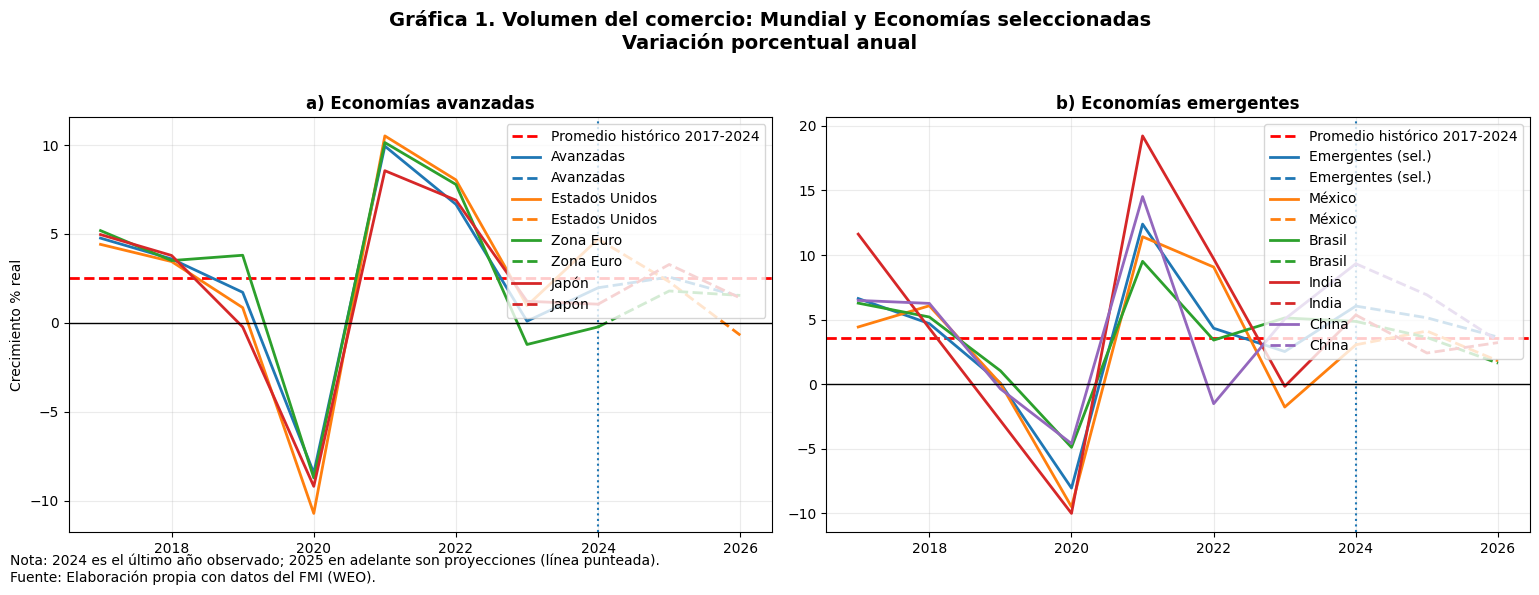

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) Cargar datos
# =========================
# Cambia este path al tuyo
path = "raw/ex_im.csv"
df = pd.read_csv(path)

# Años disponibles (columnas tipo "2017", "2018", ...)
years = [c for c in df.columns if c.isdigit()]
years = sorted(years, key=int)
years_int = list(map(int, years))

# =========================
# 2) Helpers
# =========================
def trade_volume_growth(df, country_name, years):
    """
    Calcula el crecimiento del 'volumen del comercio' como el promedio
    entre crecimiento real de exportaciones e importaciones (volume).
    Si solo existe una de las dos series, usa esa.
    """
    sub = df[df["COUNTRY"] == country_name].copy()

    sub["is_export"] = sub["INDICATOR"].str.contains(
        "Exports of goods and services, Volume", case=False, na=False
    )
    sub["is_import"] = sub["INDICATOR"].str.contains(
        "Imports of goods and services, Volume", case=False, na=False
    )

    ex = sub[sub["is_export"]]
    im = sub[sub["is_import"]]

    def mean_series(x):
        if x.empty:
            return None
        return x[years].apply(pd.to_numeric, errors="coerce").mean(axis=0)

    ex_s = mean_series(ex)
    im_s = mean_series(im)

    if ex_s is None and im_s is None:
        raise ValueError(f"No encontré series export/import volume para: {country_name}")

    if ex_s is None:
        vol = im_s
    elif im_s is None:
        vol = ex_s
    else:
        vol = (ex_s + im_s) / 2.0

    return vol.astype(float)

def plot_solid_then_dashed(ax, x, y, split_year=2024, **kwargs):
    """
    Dibuja línea sólida hasta split_year y punteada después,
    manteniendo exactamente el mismo color.
    """
    x = np.array(x)
    y = np.array(y, dtype=float)

    mask_solid = x <= split_year
    mask_dashed = x >= split_year  # incluye split_year para conectar bien

    # sólida
    line, = ax.plot(x[mask_solid], y[mask_solid], **kwargs)
    color = line.get_color()

    # punteada con el MISMO color
    dashed_kwargs = dict(kwargs)
    dashed_kwargs["linestyle"] = "--"
    dashed_kwargs["color"] = color
    ax.plot(x[mask_dashed], y[mask_dashed], **dashed_kwargs)

# =========================
# 3) Configuración de la figura
# =========================
last_observed_year = 2024

# Promedio histórico: usa el rango que tengas en tu CSV
# (Si tu archivo solo tiene 2017–2026, deja esto así)
hist_start, hist_end = 2017, 2024

# Series por panel (incluye Japón en avanzadas)
advanced_series = [
    ("Mundial", "World"),  # bórralo si no existe en tu CSV
    ("Avanzadas", "Advanced Economies"),
    ("Estados Unidos", "United States"),
    ("Zona Euro", "Euro Area (EA)"),
    ("Japón", "Japan"),
]

emerging_series = [
    ("Emergentes (sel.)", "Emerging Market and Developing Economies"),
    ("México", "Mexico"),
    ("Brasil", "Brazil"),
    ("India", "India"),
    ("China", "China, People's Republic of"),
]

# =========================
# 4) Construir figura (2 paneles)
# =========================
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.5), sharey=False)

fig.suptitle(
    "Gráfica 1. Volumen del comercio: Mundial y Economías seleccionadas\n"
    "Variación porcentual anual",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

# ---------- Panel a: Avanzadas ----------
ax = axes[0]
ax.set_title("a) Economías avanzadas", fontsize=12, fontweight="bold")

# Promedio histórico (tomado del grupo 'Advanced Economies')
adv_group = trade_volume_growth(df, "Advanced Economies", years)
hist_mask_adv = [(y >= hist_start) and (y <= hist_end) for y in years_int]
hist_avg_adv = float(np.nanmean(adv_group.values[hist_mask_adv]))

ax.axhline(
    hist_avg_adv, linestyle="--", linewidth=2, color="red",
    label=f"Promedio histórico {hist_start}-{hist_end}"
)

# Línea vertical separando observado/proyección
ax.axvline(last_observed_year, linestyle=":", linewidth=1.5)

# Series avanzadas
for label, country in advanced_series:
    try:
        s = trade_volume_growth(df, country, years)
        plot_solid_then_dashed(
            ax, years_int, s.values,
            split_year=last_observed_year,
            linewidth=2,
            label=label
        )
    except ValueError:
        # Si no existe en el CSV, se salta sin romper
        continue

ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Crecimiento % real")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", frameon=True)

# (Opcional) límites tipo el ejemplo
# ax.set_ylim(-3, 6)

# ---------- Panel b: Emergentes ----------
ax = axes[1]
ax.set_title("b) Economías emergentes", fontsize=12, fontweight="bold")

# Promedio histórico (tomado del grupo 'Emerging Market and Developing Economies')
em_group = trade_volume_growth(df, "Emerging Market and Developing Economies", years)
hist_mask_em = [(y >= hist_start) and (y <= hist_end) for y in years_int]
hist_avg_em = float(np.nanmean(em_group.values[hist_mask_em]))

ax.axhline(
    hist_avg_em, linestyle="--", linewidth=2, color="red",
    label=f"Promedio histórico {hist_start}-{hist_end}"
)

ax.axvline(last_observed_year, linestyle=":", linewidth=1.5)

# Series emergentes
for label, country in emerging_series:
    try:
        s = trade_volume_growth(df, country, years)
        plot_solid_then_dashed(
            ax, years_int, s.values,
            split_year=last_observed_year,
            linewidth=2,
            label=label
        )
    except ValueError:
        continue

ax.axhline(0, color="black", linewidth=1)
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", frameon=True)

# (Opcional) límites tipo el ejemplo
# ax.set_ylim(-5, 13)

# Nota y fuente
fig.text(
    0.01, -0.02,
    f"Nota: {last_observed_year} es el último año observado; "
    f"{last_observed_year+1} en adelante son proyecciones (línea punteada).\n"
    "Fuente: Elaboración propia con datos del FMI (WEO).",
    fontsize=10
)

plt.tight_layout()
plt.show()


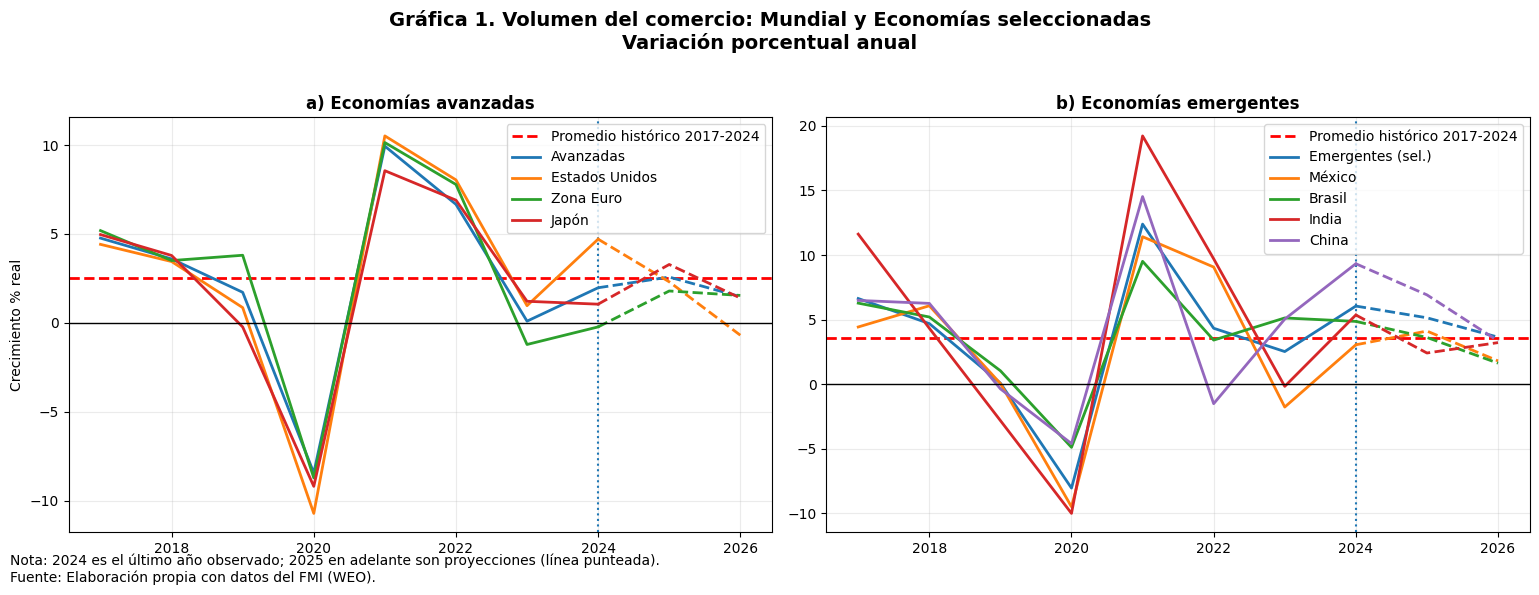

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) Cargar datos
# =========================
path = "raw/ex_im.csv"
df = pd.read_csv(path)

years = [c for c in df.columns if c.isdigit()]
years = sorted(years, key=int)
years_int = list(map(int, years))

# =========================
# 2) Helpers
# =========================
def trade_volume_growth(df, country_name, years):
    sub = df[df["COUNTRY"] == country_name].copy()

    sub["is_export"] = sub["INDICATOR"].str.contains(
        "Exports of goods and services, Volume", case=False, na=False
    )
    sub["is_import"] = sub["INDICATOR"].str.contains(
        "Imports of goods and services, Volume", case=False, na=False
    )

    ex = sub[sub["is_export"]]
    im = sub[sub["is_import"]]

    def mean_series(x):
        if x.empty:
            return None
        return x[years].apply(pd.to_numeric, errors="coerce").mean(axis=0)

    ex_s = mean_series(ex)
    im_s = mean_series(im)

    if ex_s is None and im_s is None:
        raise ValueError(country_name)

    if ex_s is None:
        vol = im_s
    elif im_s is None:
        vol = ex_s
    else:
        vol = (ex_s + im_s) / 2

    return vol.astype(float)

def plot_solid_then_dashed(ax, x, y, split_year, label, linewidth=2):
    """
    Dibuja sólida + punteada con mismo color.
    SOLO la sólida lleva label → evita duplicados en leyenda.
    """
    x = np.array(x)
    y = np.array(y)

    mask_solid = x <= split_year
    mask_dashed = x >= split_year

    line, = ax.plot(
        x[mask_solid],
        y[mask_solid],
        linewidth=linewidth,
        label=label
    )

    color = line.get_color()

    ax.plot(
        x[mask_dashed],
        y[mask_dashed],
        linestyle="--",
        linewidth=linewidth,
        color=color
    )

# =========================
# 3) Configuración
# =========================
last_observed_year = 2024
hist_start, hist_end = 2017, 2024

advanced_series = [
    ("Avanzadas", "Advanced Economies"),
    ("Estados Unidos", "United States"),
    ("Zona Euro", "Euro Area (EA)"),
    ("Japón", "Japan"),
]

emerging_series = [
    ("Emergentes (sel.)", "Emerging Market and Developing Economies"),
    ("México", "Mexico"),
    ("Brasil", "Brazil"),
    ("India", "India"),
    ("China", "China, People's Republic of"),
]

# =========================
# 4) Figura
# =========================
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.5))

fig.suptitle(
    "Gráfica 1. Volumen del comercio: Mundial y Economías seleccionadas\n"
    "Variación porcentual anual",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

# ---------- Panel a ----------
ax = axes[0]
ax.set_title("a) Economías avanzadas", fontweight="bold")

adv_group = trade_volume_growth(df, "Advanced Economies", years)
hist_mask_adv = [(y >= hist_start) & (y <= hist_end) for y in years_int]
hist_avg_adv = np.nanmean(adv_group.values[hist_mask_adv])

ax.axhline(
    hist_avg_adv,
    linestyle="--",
    linewidth=2,
    color="red",
    label=f"Promedio histórico {hist_start}-{hist_end}"
)

ax.axvline(last_observed_year, linestyle=":", linewidth=1.5)

for label, country in advanced_series:
    try:
        s = trade_volume_growth(df, country, years)
        plot_solid_then_dashed(
            ax,
            years_int,
            s.values,
            last_observed_year,
            label
        )
    except ValueError:
        continue

ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Crecimiento % real")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")

# ---------- Panel b ----------
ax = axes[1]
ax.set_title("b) Economías emergentes", fontweight="bold")

em_group = trade_volume_growth(
    df,
    "Emerging Market and Developing Economies",
    years
)

hist_mask_em = [(y >= hist_start) & (y <= hist_end) for y in years_int]
hist_avg_em = np.nanmean(em_group.values[hist_mask_em])

ax.axhline(
    hist_avg_em,
    linestyle="--",
    linewidth=2,
    color="red",
    label=f"Promedio histórico {hist_start}-{hist_end}"
)

ax.axvline(last_observed_year, linestyle=":", linewidth=1.5)

for label, country in emerging_series:
    try:
        s = trade_volume_growth(df, country, years)
        plot_solid_then_dashed(
            ax,
            years_int,
            s.values,
            last_observed_year,
            label
        )
    except ValueError:
        continue

ax.axhline(0, color="black", linewidth=1)
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")

# ---------- Nota ----------
fig.text(
    0.01,
    -0.02,
    f"Nota: {last_observed_year} es el último año observado; "
    f"{last_observed_year+1} en adelante son proyecciones (línea punteada).\n"
    "Fuente: Elaboración propia con datos del FMI (WEO).",
    fontsize=10
)

plt.tight_layout()
plt.show()


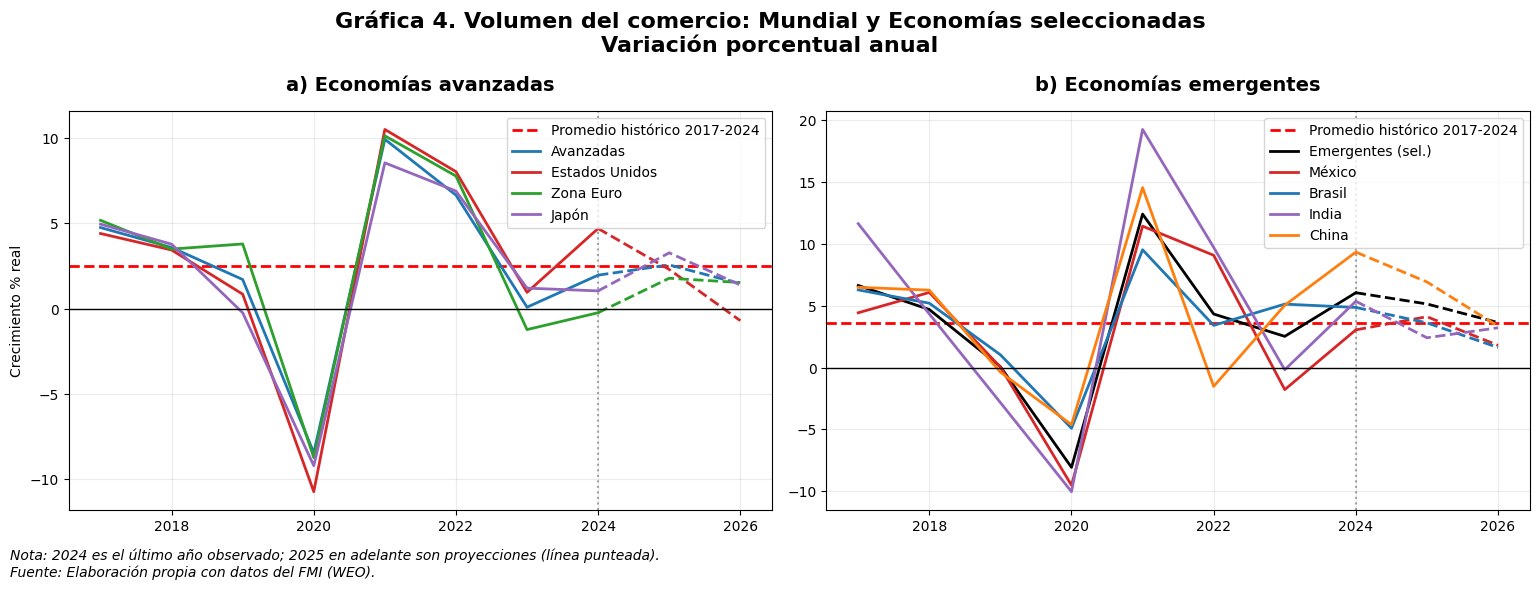

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) Cargar datos
# =========================
path = "raw/ex_im.csv"  # <-- cambia esto
df = pd.read_csv(path)

years = [c for c in df.columns if c.isdigit()]
years = sorted(years, key=int)
years_int = list(map(int, years))

# =========================
# 2) Helpers
# =========================
def trade_volume_growth(df, country_name, years):
    """
    Crecimiento del volumen del comercio = promedio entre
    crecimiento real (volume) de exportaciones e importaciones.
    """
    sub = df[df["COUNTRY"] == country_name].copy()

    sub["is_export"] = sub["INDICATOR"].str.contains(
        "Exports of goods and services, Volume", case=False, na=False
    )
    sub["is_import"] = sub["INDICATOR"].str.contains(
        "Imports of goods and services, Volume", case=False, na=False
    )

    ex = sub[sub["is_export"]]
    im = sub[sub["is_import"]]

    def mean_series(x):
        if x.empty:
            return None
        return x[years].apply(pd.to_numeric, errors="coerce").mean(axis=0)

    ex_s = mean_series(ex)
    im_s = mean_series(im)

    if ex_s is None and im_s is None:
        raise ValueError(f"No encontré series export/import volume para: {country_name}")

    if ex_s is None:
        vol = im_s
    elif im_s is None:
        vol = ex_s
    else:
        vol = (ex_s + im_s) / 2.0

    return vol.astype(float)

def plot_solid_then_dashed(ax, x, y, split_year, label, color, linewidth=2):
    """
    Línea sólida hasta split_year y punteada después.
    SOLO la sólida lleva label (para que la leyenda no duplique).
    Mantiene el mismo color antes/después.
    """
    x = np.array(x)
    y = np.array(y, dtype=float)

    mask_solid = x <= split_year
    mask_dashed = x >= split_year  # incluye el split para conectar bien

    ax.plot(
        x[mask_solid], y[mask_solid],
        color=color, linewidth=linewidth, label=label
    )
    ax.plot(
        x[mask_dashed], y[mask_dashed],
        color=color, linewidth=linewidth, linestyle="--"
    )

# =========================
# 3) Configuración estilo (colores EXACTOS como tu gráfica de PIB)
# =========================
# Paleta tipo Matplotlib "tab:" que coincide con lo que se ve en tu ejemplo
COLORS = {
    "Mundial": "black",
    "Avanzadas": "tab:blue",
    "Estados Unidos": "tab:red",
    "Zona Euro": "tab:green",
    "Japón": "tab:purple",          # (en tu ejemplo no aparece Japón; lo fijamos en morado)
    "Emergentes (sel.)": "black",
    "México": "tab:red",
    "Chile": "tab:green",
    "Brasil": "tab:blue",
    "India": "tab:purple",
    "China": "tab:orange",
}

last_observed_year = 2024

# Promedio histórico: ajusta al rango que tengas en tu CSV.
# Si tu CSV solo trae 2017–2026, deja 2017–2024.
hist_start, hist_end = 2017, 2024

# Series (nombres de leyenda, nombre exacto en COUNTRY)
advanced_series = [
    ("Avanzadas", "Advanced Economies"),
    ("Estados Unidos", "United States"),
    ("Zona Euro", "Euro Area (EA)"),
    ("Japón", "Japan"),
]

emerging_series = [
    ("Emergentes (sel.)", "Emerging Market and Developing Economies"),
    ("México", "Mexico"),
    ("Brasil", "Brazil"),
    ("India", "India"),
    ("China", "China, People's Republic of"),
    # Si luego quieres Chile y tu CSV lo trae, descomenta:
    # ("Chile", "Chile"),
]

# =========================
# 4) Figura (2 paneles)
# =========================
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.5))

fig.suptitle(
    "Gráfica 4. Volumen del comercio: Mundial y Economías seleccionadas\n"
    "Variación porcentual anual",
    fontsize=16, fontweight="bold", y=0.98
)

# ---------- Panel a: Avanzadas ----------
ax = axes[0]
ax.set_title("a) Economías avanzadas", fontsize=14, fontweight="bold", pad=15)

# Promedio histórico (línea roja punteada) usando Avanzadas como referencia
adv_group = trade_volume_growth(df, "Advanced Economies", years)
hist_mask_adv = [(y >= hist_start) and (y <= hist_end) for y in years_int]
hist_avg_adv = float(np.nanmean(adv_group.values[hist_mask_adv]))

ax.axhline(
    hist_avg_adv, linestyle="--", linewidth=2, color="red",
    label=f"Promedio histórico {hist_start}-{hist_end}"
)

# Línea vertical (último observado)
ax.axvline(last_observed_year, linestyle=":", linewidth=1.5, color="gray", alpha=0.7)

# Series avanzadas (con colores fijados)
for label, country in advanced_series:
    try:
        s = trade_volume_growth(df, country, years)
        plot_solid_then_dashed(
            ax, years_int, s.values,
            split_year=last_observed_year,
            label=label,
            color=COLORS[label],
            linewidth=2
        )
    except ValueError:
        continue

ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Crecimiento % real")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", frameon=True)

# ---------- Panel b: Emergentes ----------
ax = axes[1]
ax.set_title("b) Economías emergentes", fontsize=14, fontweight="bold", pad=15)

# Promedio histórico (línea roja punteada) usando Emergentes como referencia
em_group = trade_volume_growth(df, "Emerging Market and Developing Economies", years)
hist_mask_em = [(y >= hist_start) and (y <= hist_end) for y in years_int]
hist_avg_em = float(np.nanmean(em_group.values[hist_mask_em]))

ax.axhline(
    hist_avg_em, linestyle="--", linewidth=2, color="red",
    label=f"Promedio histórico {hist_start}-{hist_end}"
)

ax.axvline(last_observed_year, linestyle=":", linewidth=1.5, color="gray", alpha=0.7)

# Series emergentes (con colores fijados)
for label, country in emerging_series:
    try:
        s = trade_volume_growth(df, country, years)
        plot_solid_then_dashed(
            ax, years_int, s.values,
            split_year=last_observed_year,
            label=label,
            color=COLORS[label],
            linewidth=2
        )
    except ValueError:
        continue

ax.axhline(0, color="black", linewidth=1)
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", frameon=True)

# Nota y fuente
fig.text(
    0.01, -0.05,
    f"Nota: {last_observed_year} es el último año observado; "
    f"{last_observed_year+1} en adelante son proyecciones (línea punteada).\n"
    "Fuente: Elaboración propia con datos del FMI (WEO).",
    fontsize=10, style="italic"
)

plt.tight_layout()
plt.show()
